In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("All imports done")

All imports done


In [2]:
X_train_res = joblib.load('../data/X_train_res.pkl')
y_train_res = joblib.load('../data/y_train_res.pkl')
X_test      = joblib.load('../data/X_test.pkl')
y_test      = joblib.load('../data/y_test.pkl')

print("=== DATA LOADED ===")
print(f"X_train (SMOTE) : {X_train_res.shape}")
print(f"X_test          : {X_test.shape}")
print(f"\nTraining class balance:")
print(pd.Series(y_train_res).value_counts())
print(f"\nTest class balance:")
print(pd.Series(y_test).value_counts())

=== DATA LOADED ===
X_train (SMOTE) : (454902, 35)
X_test          : (56962, 35)

Training class balance:
Class
0    227451
1    227451
Name: count, dtype: int64

Test class balance:
Class
0    56864
1       98
Name: count, dtype: int64


In [3]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    class_weight='balanced',  # extra safety on top of SMOTE
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr.fit(X_train_res, y_train_res)

print("Training complete")
print(f"Converged in {lr.n_iter_[0]} iterations")

Training Logistic Regression...
Training complete
Converged in 163 iterations


In [4]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("=== PREDICTIONS DONE ===")
print(f"Total test samples : {len(y_test):,}")
print(f"Predicted fraud    : {y_pred.sum():,}")
print(f"Actual fraud       : {y_test.sum():,}")

=== PREDICTIONS DONE ===
Total test samples : 56,962
Predicted fraud    : 1,642
Actual fraud       : 98


In [5]:
print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

roc  = roc_auc_score(y_test, y_prob)
prauc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC  : {roc:.4f}")
print(f"PR-AUC   : {prauc:.4f}")

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC  : 0.9736
PR-AUC   : 0.7316


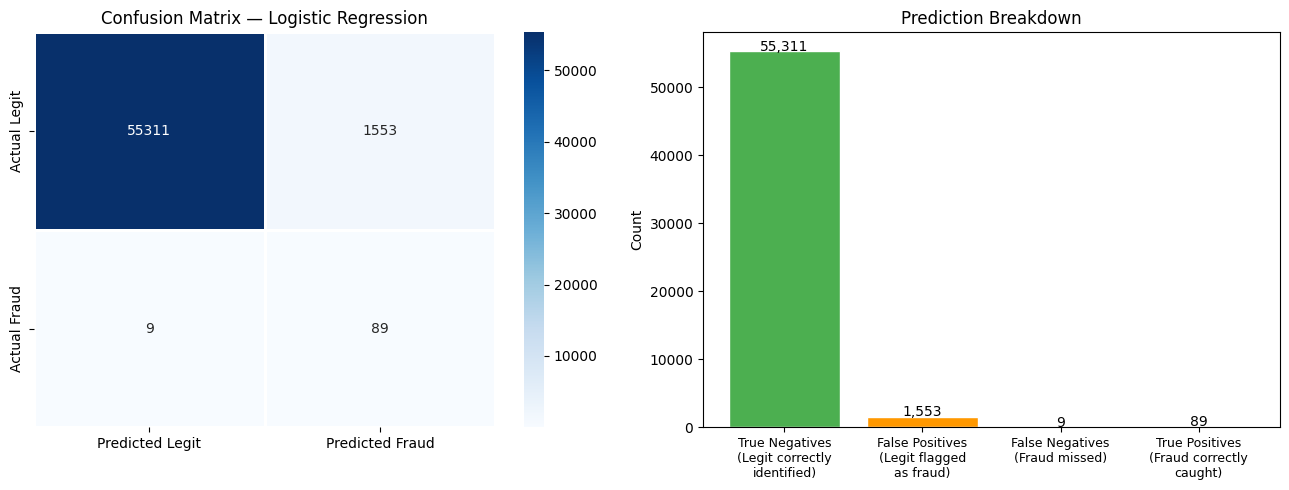


True Negatives  (legit correct) : 55,311
False Positives (legit as fraud): 1,553
False Negatives (fraud missed)  : 9
True Positives  (fraud caught)  : 89

Fraud catch rate : 90.8%
False alarm rate : 2.73%


In [6]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'],
            ax=axes[0], linewidths=1)
axes[0].set_title('Confusion Matrix — Logistic Regression')

# Business breakdown
labels = ['True Negatives\n(Legit correctly\nidentified)',
          'False Positives\n(Legit flagged\nas fraud)',
          'False Negatives\n(Fraud missed)',
          'True Positives\n(Fraud correctly\ncaught)']
values = [tn, fp, fn, tp]
colors = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']

bars = axes[1].bar(range(4), values, color=colors, edgecolor='white')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_title('Prediction Breakdown')
axes[1].set_ylabel('Count')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/08_lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives  (legit correct) : {tn:,}")
print(f"False Positives (legit as fraud): {fp:,}")
print(f"False Negatives (fraud missed)  : {fn:,}")
print(f"True Positives  (fraud caught)  : {tp:,}")
print(f"\nFraud catch rate : {tp/(tp+fn)*100:.1f}%")
print(f"False alarm rate : {fp/(fp+tn)*100:.2f}%")

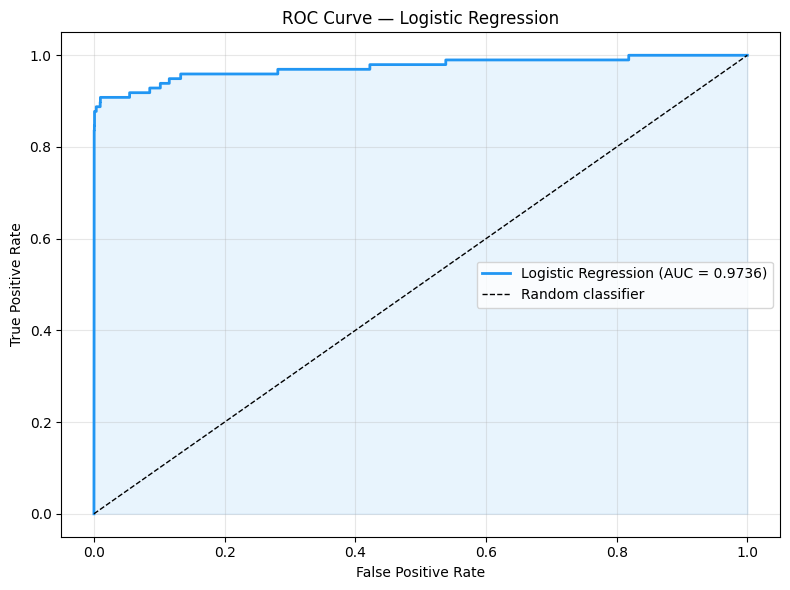

In [7]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2,
         label=f'Logistic Regression (AUC = {roc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/09_lr_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

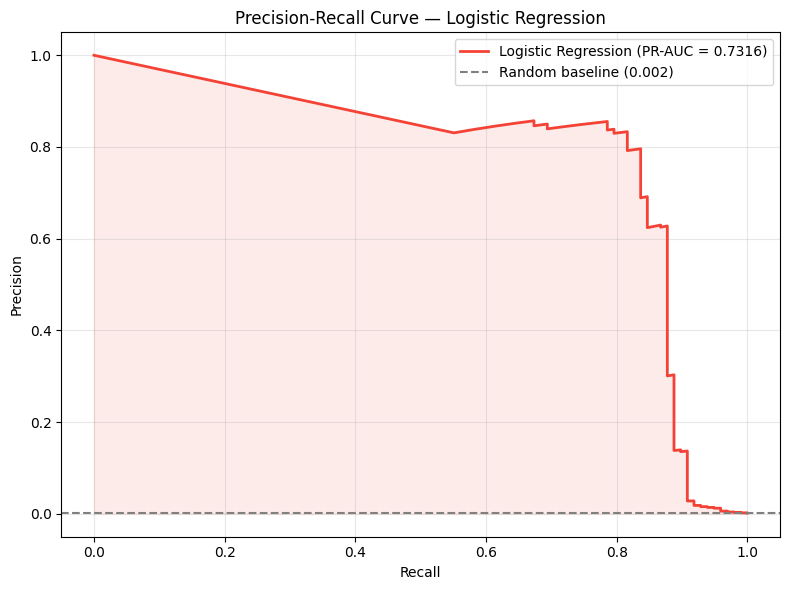

In [8]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#F44336', linewidth=2,
         label=f'Logistic Regression (PR-AUC = {prauc:.4f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f'Random baseline ({y_test.mean():.3f})')
plt.fill_between(recall, precision, alpha=0.1, color='#F44336')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/10_lr_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Default threshold is 0.5 — but we can do better
# Find threshold where recall >= 0.85 with best precision

target_recall = 0.85
valid_idx = np.where(recall[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    best_idx       = valid_idx[np.argmax(precision[:-1][valid_idx])]
    best_threshold = thresholds_pr[best_idx]
    best_precision = precision[best_idx]
    best_recall    = recall[best_idx]
else:
    best_threshold = 0.5
    best_precision = 0
    best_recall    = 0

print(f"=== THRESHOLD OPTIMIZATION ===")
print(f"Target recall    : {target_recall}")
print(f"Best threshold   : {best_threshold:.4f}")
print(f"Precision at this threshold: {best_precision:.4f}")
print(f"Recall at this threshold   : {best_recall:.4f}")

# Apply optimized threshold
y_pred_opt = (y_prob >= best_threshold).astype(int)

print(f"\n=== WITH OPTIMIZED THRESHOLD ===")
print(classification_report(y_test, y_pred_opt,
      target_names=['Legitimate', 'Fraud']))

=== THRESHOLD OPTIMIZATION ===
Target recall    : 0.85
Best threshold   : 0.9980
Precision at this threshold: 0.6296
Recall at this threshold   : 0.8673

=== WITH OPTIMIZED THRESHOLD ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.63      0.87      0.73        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962



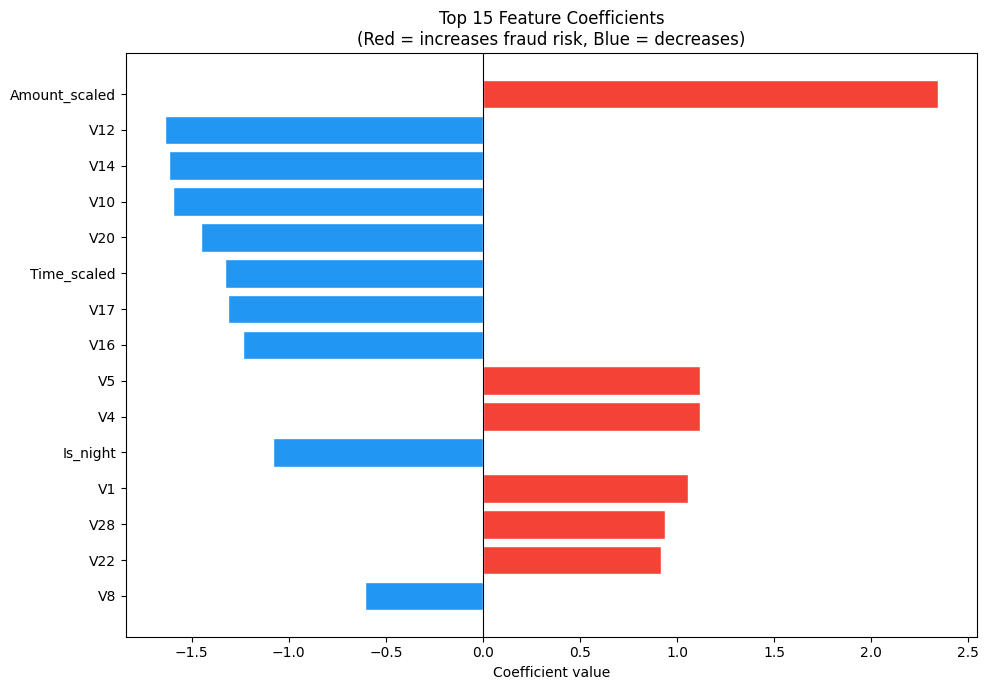


Top 10 features by importance:
      Feature  Coefficient
Amount_scaled     2.346383
          V12    -1.639961
          V14    -1.614598
          V10    -1.597226
          V20    -1.453500
  Time_scaled    -1.330590
          V17    -1.311506
          V16    -1.233543
           V5     1.120297
           V4     1.118963


In [10]:
feature_names = X_test.columns.tolist()
coefficients  = lr.coef_[0]

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients,
    'Abs_Coef'   : np.abs(coefficients)
}).sort_values('Abs_Coef', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))

top15 = coef_df.head(15)
colors = ['#F44336' if c > 0 else '#2196F3'
          for c in top15['Coefficient']]

ax.barh(top15['Feature'], top15['Coefficient'],
        color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 15 Feature Coefficients\n(Red = increases fraud risk, Blue = decreases)',
             fontsize=12)
ax.set_xlabel('Coefficient value')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../data/11_lr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features by importance:")
print(coef_df[['Feature', 'Coefficient']].head(10).to_string(index=False))

In [11]:
# Save model
joblib.dump(lr, '../models/baseline_lr.pkl')

# Save threshold
joblib.dump(best_threshold, '../models/baseline_threshold.pkl')

# Save results as dict for comparison later in notebook 6
baseline_results = {
    'model'    : 'Logistic Regression',
    'roc_auc'  : round(roc, 4),
    'pr_auc'   : round(prauc, 4),
    'threshold': round(best_threshold, 4),
    'precision': round(best_precision, 4),
    'recall'   : round(best_recall, 4),
    'f1'       : round(2 * best_precision * best_recall /
                       (best_precision + best_recall + 1e-9), 4)
}

joblib.dump(baseline_results, '../models/baseline_results.pkl')

print("=== FILES SAVED ===")
print("models/baseline_lr.pkl")
print("models/baseline_threshold.pkl")
print("models/baseline_results.pkl")
print(f"\nBaseline scores:")
for k, v in baseline_results.items():
    if k != 'model':
        print(f"  {k:12}: {v}")

=== FILES SAVED ===
models/baseline_lr.pkl
models/baseline_threshold.pkl
models/baseline_results.pkl

Baseline scores:
  roc_auc     : 0.9736
  pr_auc      : 0.7316
  threshold   : 0.998
  precision   : 0.6296
  recall      : 0.8673
  f1          : 0.7296


In [12]:
print("=" * 50)
print("    BASELINE MODEL COMPLETE")
print("=" * 50)
print(f"""
MODEL
  Logistic Regression (class_weight=balanced)
  Trained on SMOTE-balanced data

SCORES
  ROC-AUC  : {roc:.4f}
  PR-AUC   : {prauc:.4f}

THIS IS YOUR BASELINE
  Any model in notebook 04 must beat these
  numbers to be worth using in production.

WHAT TO EXPECT FROM XGBOOST
  ROC-AUC  : 0.97+
  PR-AUC   : 0.83+
  Recall   : 0.85+

NEXT STEP
  → Open 04_models.ipynb
""")
print("=" * 50)

    BASELINE MODEL COMPLETE

MODEL
  Logistic Regression (class_weight=balanced)
  Trained on SMOTE-balanced data

SCORES
  ROC-AUC  : 0.9736
  PR-AUC   : 0.7316

THIS IS YOUR BASELINE
  Any model in notebook 04 must beat these
  numbers to be worth using in production.

WHAT TO EXPECT FROM XGBOOST
  ROC-AUC  : 0.97+
  PR-AUC   : 0.83+
  Recall   : 0.85+

NEXT STEP
  → Open 04_models.ipynb

